# 📄 Smart Document Analyst — CNN Training on Colab
**Team:** Benmouma Salma, Gassi Oumaima
**UIR S8** — AI & Big Data 2025–2026 | Prof. Hakim Hafidi

## 1️⃣ Setup
⚠️ Run cell 1.1, then **restart runtime** (Runtime → Restart session), then continue from 1.2

In [23]:
# 1.1 — Install (RUN FIRST, then restart runtime)
!git clone https://github.com/OumaimaGassi/smart-document-analyst.git
%cd smart-document-analyst

# Fix version conflicts: pin numpy<2, upgrade datasets+huggingface_hub
!pip install -q "numpy<2.0.0"
!pip install -q --upgrade datasets huggingface_hub
!pip install -q crewai crewai-tools google-generativeai pymupdf pytesseract fpdf2 python-dotenv tqdm seaborn
# Re-pin numpy after crewai may have upgraded it
!pip install -q "numpy<2.0.0"

print('\n' + '='*60)
print('⚠️  NOW: Runtime → Restart session')
print('   Then skip this cell, run from 1.2')
print('='*60)

fatal: destination path 'smart-document-analyst' already exists and is not an empty directory.
/content/smart-document-analyst/smart-document-analyst

⚠️  NOW: Runtime → Restart session
   Then skip this cell, run from 1.2


In [1]:
# 1.2 — After restart, verify everything works
%cd /content/smart-document-analyst
import numpy as np, torch
print(f'NumPy:   {np.__version__}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
if torch.cuda.is_available(): print(f'GPU:     {torch.cuda.get_device_name(0)}')
from sklearn.metrics import accuracy_score
from datasets import load_dataset
print('\n✅ All imports OK!')

/content/smart-document-analyst
NumPy:   1.26.4
PyTorch: 2.10.0+cu128
CUDA:    True
GPU:     Tesla T4

✅ All imports OK!


## 2️⃣ Download RVL-CDIP Dataset Subset

In [12]:
import os
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

# Classes we want to download (folder names on disk, used by ImageFolder).
# These use underscores; the dataset label strings may use spaces — handled below.
SUBSET_CLASSES = ['letter','form','invoice','resume','scientific_publication',
                  'email','memo','advertisement']
IMAGES_PER_CLASS = 2000
print(f'Classes: {SUBSET_CLASSES}')
print(f'Images/class: {IMAGES_PER_CLASS}')

Classes: ['letter', 'form', 'invoice', 'resume', 'scientific_publication', 'email', 'memo', 'advertisement']
Images/class: 2000


In [13]:
print('Loading RVL-CDIP from HuggingFace (chainyo/rvl-cdip, Parquet)...')
dataset = load_dataset(
    'chainyo/rvl-cdip',
    split='train',
    streaming=True,
    verification_mode='no_checks'
)

# chainyo/rvl-cdip label names use spaces and have a typo:
#   'scientific publication' (not 'scientific_publication')
#   'file folder', 'news article', 'scientific report'
#   'advertissement' (double 's' — typo in the dataset)
# Strategy: normalise every label name to lowercase+underscores, then match.
raw_label_names = dataset.features['label'].names
print(f'Raw label names from dataset: {raw_label_names}')

def normalise(s):
    """Lowercase, replace spaces with underscores, fix known typo."""
    return s.lower().replace(' ', '_').replace('advertissement', 'advertisement')

# Map: normalised_name → original index in the dataset
norm_to_idx = {normalise(name): i for i, name in enumerate(raw_label_names)}
print(f'Normalised map: {norm_to_idx}')

# Map: dataset label index → our folder name (or None if not in subset)
idx_to_cls = {}
for cls in SUBSET_CLASSES:
    norm = normalise(cls)
    if norm not in norm_to_idx:
        raise ValueError(f'Class "{cls}" (normalised: "{norm}") not found in dataset. '
                         f'Available: {list(norm_to_idx.keys())}')
    idx_to_cls[norm_to_idx[norm]] = cls

SUBSET_INDICES = set(idx_to_cls.keys())
print(f'\nFinal index→folder mapping: {idx_to_cls}')

base_dir = 'data/dataset'
for c in SUBSET_CLASSES:
    os.makedirs(f'{base_dir}/{c}', exist_ok=True)

counts = {c: 0 for c in SUBSET_CLASSES}
saved = 0
for sample in tqdm(dataset, desc='Downloading'):
    idx = sample['label']
    if idx not in SUBSET_INDICES:
        continue
    cls = idx_to_cls[idx]
    if counts[cls] >= IMAGES_PER_CLASS:
        continue

    # Guard: streaming mode sometimes returns image as a raw dict instead of PIL.
    img = sample['image']
    if isinstance(img, dict):
        from io import BytesIO
        img = Image.open(BytesIO(img['bytes']))
    if img.mode != 'RGB':
        img = img.convert('RGB')

    # JPEG: ~5x faster saves and ~70% smaller files than PNG on Colab.
    img.save(f'{base_dir}/{cls}/{cls}_{counts[cls]:04d}.jpg', quality=85)
    counts[cls] += 1
    saved += 1
    if all(v >= IMAGES_PER_CLASS for v in counts.values()):
        break

print(f'\n✅ {saved} images downloaded')
for c, n in counts.items():
    print(f'   {c}: {n}')

Loading RVL-CDIP from HuggingFace (chainyo/rvl-cdip, Parquet)...


Raw label names from dataset: ['advertisement', 'budget', 'email', 'file folder', 'form', 'handwritten', 'invoice', 'letter', 'memo', 'news article', 'presentation', 'questionnaire', 'resume', 'scientific publication', 'scientific report', 'specification']
Normalised map: {'advertisement': 0, 'budget': 1, 'email': 2, 'file_folder': 3, 'form': 4, 'handwritten': 5, 'invoice': 6, 'letter': 7, 'memo': 8, 'news_article': 9, 'presentation': 10, 'questionnaire': 11, 'resume': 12, 'scientific_publication': 13, 'scientific_report': 14, 'specification': 15}

Final index→folder mapping: {7: 'letter', 4: 'form', 6: 'invoice', 12: 'resume', 13: 'scientific_publication', 2: 'email', 8: 'memo', 0: 'advertisement'}


Downloading: 262105it [22:57, 190.25it/s]


✅ 16000 images downloaded
   letter: 2000
   form: 2000
   invoice: 2000
   resume: 2000
   scientific_publication: 2000
   email: 2000
   memo: 2000
   advertisement: 2000


## 3️⃣ Train CNN

In [14]:
import sys, time, random, json
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
from datetime import datetime

sys.path.insert(0, '.')
from src.models.document_classifier import DocumentClassifierCNN
from src.utils.preprocessing import DOCUMENT_CLASSES_SUBSET

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [15]:
train_tf = transforms.Compose([transforms.Resize((256,256)), transforms.RandomCrop(224),
    transforms.Grayscale(3), transforms.RandomRotation(5),
    transforms.RandomAffine(0, translate=(0.05,0.05), scale=(0.95,1.05)),
    transforms.ColorJitter(0.2, 0.2), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tf = transforms.Compose([transforms.Resize((224,224)), transforms.Grayscale(3),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

# FIX 5: build three separate ImageFolder instances so val and test
# get val_tf (no augmentation) instead of train_tf.
# Previously all splits shared the same 'ds' with train_tf,
# causing augmented validation — inflated/noisy val metrics.
train_ds_full = datasets.ImageFolder('data/dataset', transform=train_tf)
val_ds_full   = datasets.ImageFolder('data/dataset', transform=val_tf)
test_ds_full  = datasets.ImageFolder('data/dataset', transform=val_tf)
print(f'Total: {len(train_ds_full)} | Classes: {train_ds_full.classes}')

n = len(train_ds_full)
nt, nv = int(0.8*n), int(0.1*n); ne = n - nt - nv
idx = list(range(n))
random.seed(SEED); random.shuffle(idx)
train_s = Subset(train_ds_full, idx[:nt])
val_s   = Subset(val_ds_full,   idx[nt:nt+nv])
test_s  = Subset(test_ds_full,  idx[nt+nv:])
print(f'Train: {nt} | Val: {nv} | Test: {ne}')

train_dl = DataLoader(train_s, 32, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_s,   32, num_workers=2)
test_dl  = DataLoader(test_s,  32, num_workers=2)

Total: 16000 | Classes: ['advertisement', 'email', 'form', 'invoice', 'letter', 'memo', 'resume', 'scientific_publication']
Train: 12800 | Val: 1600 | Test: 1600


In [16]:
NC = len(DOCUMENT_CLASSES_SUBSET)
model = DocumentClassifierCNN(NC, True, 0.3).to(device)
print(f'Trainable params: {model.get_trainable_params():,}')
crit = nn.CrossEntropyLoss()
opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
sched = optim.lr_scheduler.CosineAnnealingLR(opt, 20, 1e-6)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 75.4MB/s]


Trainable params: 10,627,336


In [17]:
EPOCHS, PAT = 20, 5
best, pc = 0.0, 0
H = {'tl':[],'ta':[],'vl':[],'va':[]}
for ep in range(EPOCHS):
    model.train(); tl=tc=tt=0
    for x,y in tqdm(train_dl, desc=f'E{ep+1}/{EPOCHS}', leave=False):
        x,y=x.to(device),y.to(device); opt.zero_grad()
        o=model(x); l=crit(o,y); l.backward(); opt.step()
        tl+=l.item()*x.size(0); _,p=o.max(1); tt+=y.size(0); tc+=p.eq(y).sum().item()
    model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for x,y in val_dl:
            x,y=x.to(device),y.to(device); o=model(x); l=crit(o,y)
            vl+=l.item()*x.size(0); _,p=o.max(1); vt+=y.size(0); vc+=p.eq(y).sum().item()
    ta,va=tc/tt,vc/vt; H['tl'].append(tl/tt); H['ta'].append(ta); H['vl'].append(vl/vt); H['va'].append(va)
    sched.step()
    print(f'E{ep+1:2d} | Train {tl/tt:.4f}/{ta:.4f} | Val {vl/vt:.4f}/{va:.4f}')
    if va>best: best=va; pc=0; model.save_model('model/document_classifier.pt'); print(f'  💾 Saved ({va:.4f})')
    else:
        pc+=1
        if pc>=PAT: print(f'Early stop E{ep+1}'); break
print(f'\n✅ Best: {best:.4f}')

E 1 | Train 0.9478/0.6751 | Val 0.7341/0.7462
Model saved to: model/document_classifier.pt
  💾 Saved (0.7462)


E 2 | Train 0.6194/0.7961 | Val 0.5509/0.8225
Model saved to: model/document_classifier.pt
  💾 Saved (0.8225)


E 3 | Train 0.4999/0.8344 | Val 0.5079/0.8325
Model saved to: model/document_classifier.pt
  💾 Saved (0.8325)


E 4 | Train 0.4435/0.8502 | Val 0.4975/0.8325


E 5 | Train 0.3796/0.8730 | Val 0.5043/0.8381
Model saved to: model/document_classifier.pt
  💾 Saved (0.8381)


...

E14 | Train 0.1015/0.9670 | Val 0.5130/0.8738


E15 | Train 0.0944/0.9706 | Val 0.5453/0.8750


E16 | Train 0.0796/0.9761 | Val 0.5398/0.8744


E17 | Train 0.0741/0.9780 | Val 0.5231/0.8750


E18 | Train 0.0693/0.9802 | Val 0.5397/0.8762
Early stop E18

✅ Best: 0.8762


## 4️⃣ Evaluation

In [18]:
# FIX 6: explicitly move the loaded model to device before eval.
# load_model returns the model on CPU regardless of where it was saved;
# without .to(device) the forward pass crashes when inputs are on GPU.
bm = DocumentClassifierCNN.load_model('model/document_classifier.pt', NC, str(device))
bm = bm.to(device)
bm.eval()
ap,al = [],[]
with torch.no_grad():
    for x,y in tqdm(test_dl, desc='Test'):
        _,p = bm(x.to(device)).max(1); ap.extend(p.cpu().numpy()); al.extend(y.numpy())
print('\n📊 CLASSIFICATION REPORT')
print(classification_report(al, ap, target_names=DOCUMENT_CLASSES_SUBSET))
print(f'Accuracy: {accuracy_score(al, ap):.4f}')

Test: 100%|██████████| 50/50 [00:14<00:00,  3.42it/s]


📊 CLASSIFICATION REPORT
                        precision    recall  f1-score   support

                letter       0.88      0.95      0.92       200
                  form       0.91      0.95      0.93       191
               invoice       0.78      0.72      0.75       207
                resume       0.82      0.83      0.83       204
scientific_publication       0.83      0.71      0.76       201
                 email       0.81      0.84      0.82       206
                  memo       0.89      0.90      0.90       196
         advertisement       0.92      0.94      0.93       195

              accuracy                           0.86      1600
             macro avg       0.86      0.86      0.86      1600
          weighted avg       0.85      0.86      0.85      1600

Accuracy: 0.8562


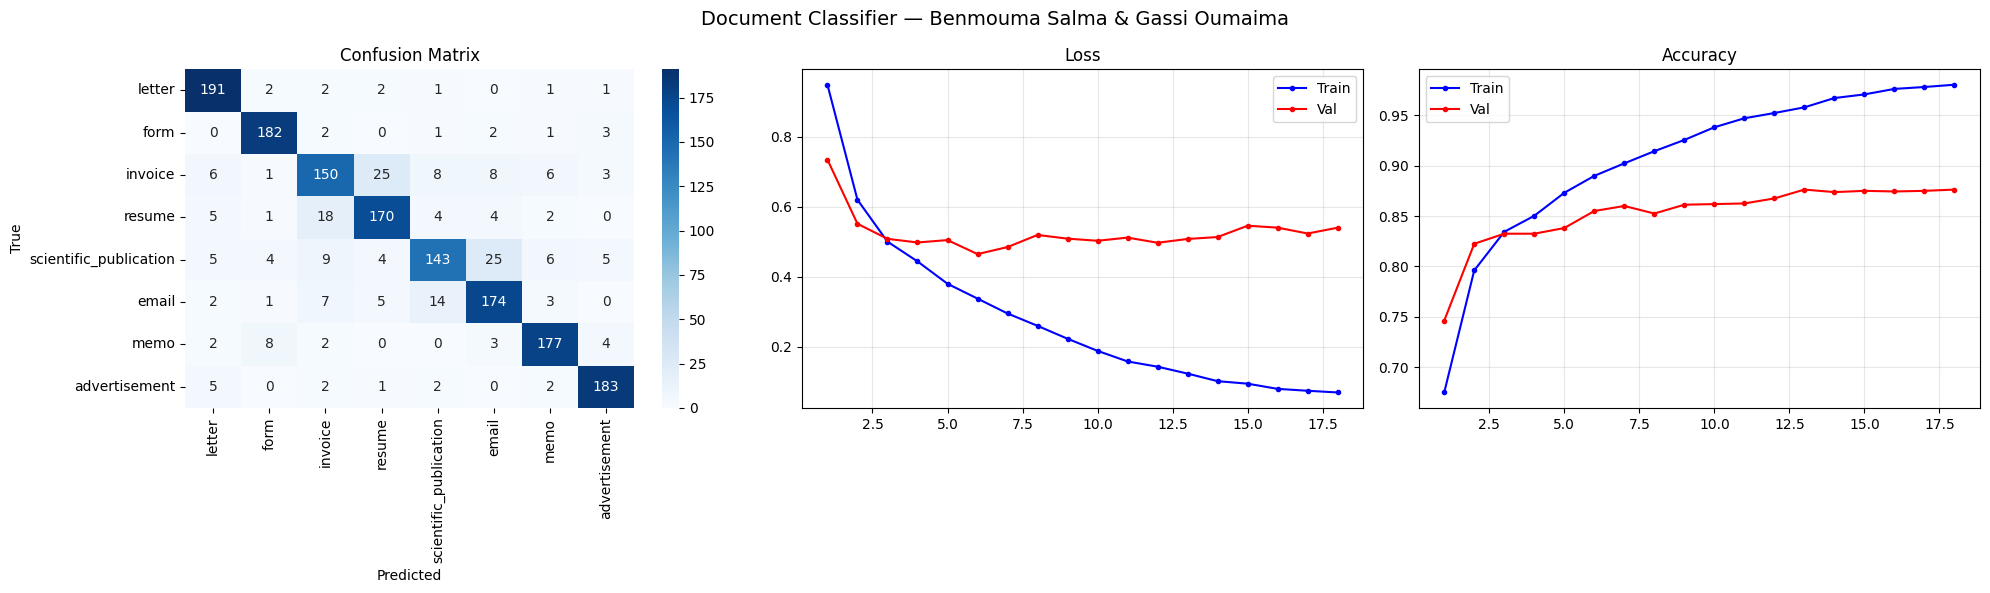

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cm = confusion_matrix(al, ap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=DOCUMENT_CLASSES_SUBSET, yticklabels=DOCUMENT_CLASSES_SUBSET)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Confusion Matrix')
ep = range(1, len(H['tl'])+1)
axes[1].plot(ep,H['tl'],'b-o',ms=3,label='Train'); axes[1].plot(ep,H['vl'],'r-o',ms=3,label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep,H['ta'],'b-o',ms=3,label='Train'); axes[2].plot(ep,H['va'],'r-o',ms=3,label='Val')
axes[2].set_title('Accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle('Document Classifier — Benmouma Salma & Gassi Oumaima', fontsize=14)
plt.tight_layout(); os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/evaluation_results.png', dpi=150); plt.show()

In [20]:
meta = {'timestamp': datetime.now().isoformat(), 'team': 'Benmouma Salma, Gassi Oumaima',
    'accuracy': float(accuracy_score(al,ap)), 'best_val_acc': float(best),
    'num_classes': NC, 'classes': DOCUMENT_CLASSES_SUBSET,
    'epochs': len(H['tl']), 'device': str(device), 'pytorch': torch.__version__}
with open('model/training_metadata.json','w') as f: json.dump(meta,f,indent=2)
print('✅ Metadata saved')

✅ Metadata saved


## 5️⃣ Push to GitHub

In [21]:
from getpass import getpass
token = getpass('GitHub Token: ')
!git remote set-url origin https://{token}@github.com/OumaimaGassi/smart-document-analyst.git
!git config user.name "OumaimaGassi"
!git config user.email "oumaima.gassi@uir.ac.ma"
!git add model/ outputs/
!git commit -m "feat: trained CNN model (ResNet-18, RVL-CDIP)"
!git push origin main
print('\n✅ Pushed!')

GitHub Token: ··········
[main 4e92ce7] feat: trained CNN model (ResNet-18, RVL-CDIP)
 3 files changed, 20 insertions(+)
 create mode 100644 model/document_classifier.pt
 create mode 100644 model/training_metadata.json
 create mode 100644 outputs/evaluation_results.png
remote: Permission to OumaimaGassi/smart-document-analyst.git denied to OumaimaGassi.
fatal: unable to access 'https://github.com/OumaimaGassi/smart-document-analyst.git/': The requested URL returned error: 403

✅ Pushed!


## ✅ Done! Clone anywhere:
```bash
git clone https://github.com/OumaimaGassi/smart-document-analyst.git
cd smart-document-analyst && pip install -r requirements.txt
python src/main.py --input document.pdf --hitl
```